In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- CONFIGURACIÓN DEL PATH (Para leer la carpeta 'src') ---
current_dir = os.getcwd()
src_path = os.path.join(current_dir, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

# --- IMPORTACIONES ---
from utils import set_global_seed
from armbinomial import ArmBinomial
from algorithms import Algorithm, EpsilonGreedy, UCB1, Softmax, EpsilonDecay, GradientBandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics, plot_smoothed_curves

# Configuración de la semilla global (Reproducibilidad - Sección 5.4)
SEED = 2024
set_global_seed(SEED)

/home/mike/EsamiMagistrale/Erasmus/ral/Sechi_Corona/k_brazos/src/plotting.py:150: SyntaxWarning: invalid escape sequence '\h'
  rects1 = ax.bar(x - width/2, q_vals, width, color=est_colors, edgecolor='black', alpha=0.9, label='Valor Estimado ($\hat{Q}$)')
/home/mike/EsamiMagistrale/Erasmus/ral/Sechi_Corona/k_brazos/src/plotting.py:151: SyntaxWarning: invalid escape sequence '\m'
  rects2 = ax.bar(x + width/2, true_means, width, color=real_color, edgecolor='black', alpha=0.5, hatch='//', label='Valor Real ($\mu$)')


Configurando semilla global (Global Seed): 2024
Dispositivo GPU detectado y configurado para determinismo.


## 1. Escenario Experimental: Optimización de Promociones (App de Delivery)

Siguiendo el **Anexo 5.1** del documento, simulamos un escenario de optimización para una plataforma de *Delivery* (tipo Uber Eats, Rappi o Glovo).

### Contexto del Negocio
La plataforma dispone de $k=5$ tipos de promociones (descuentos, envíos gratis, 2x1, etc.).
- Las promociones se asignan por **lotes de usuarios** (Batch) para medir su efectividad.
- **Tamaño del Lote ($n$):** 50 usuarios. Cada vez que elegimos una promoción (acción), se la mostramos a 50 usuarios nuevos.
- **Recompensa ($r$):** Número de usuarios del lote que utilizaron la promoción.
    - $r \in [0, 50]$
    - Esto sigue una **Distribución Binomial** $B(n, p)$.

### Configuración del Problema
Las probabilidades reales de conversión ($p$) son desconocidas para el agente. Hemos diseñado un escenario competitivo:
- **Promo C (Óptima):** $p=0.18$ (Esperado: $50 \times 0.18 = 9$ conversiones/lote).
- **Promo A (Competidora):** $p=0.16$ (Esperado: 8 conversiones).
- **Promo E (Competidora):** $p=0.15$ (Esperado: 7.5 conversiones).
- **Resto:** $p < 0.10$.

El desafío aquí es la **Varianza**: en un lote de 50, la Promo A (0.16) puede tener suerte y obtener 12 conversiones, superando temporalmente a la Promo C (0.18). Los algoritmos deben ser robustos a este "ruido" estadístico.

In [2]:
# --- Configuración del Entorno Binomial ---

# Probabilidades reales de conversión (p) para cada promoción
# El brazo 2 (índice 2) es el óptimo con p=0.18
BANDIT_PROBS = [0.16, 0.05, 0.18, 0.08, 0.15] 
K_ARMS = len(BANDIT_PROBS)

# Parámetro n de la Binomial (Tamaño del lote de usuarios)
BATCH_SIZE = 50 

# Horizonte temporal (Número de lotes a probar)
N_STEPS = 6000

# Número de ejecuciones para promediar (Monte Carlo)
N_RUNS = 500

# Cálculo de valores esperados para referencia
# Recompensa esperada = n * p
EXPECTED_REWARDS = [p * BATCH_SIZE for p in BANDIT_PROBS]
OPTIMAL_REWARD = max(EXPECTED_REWARDS)

print("--- Configuración Delivery App ---")
print(f"Tamaño del Lote (n): {BATCH_SIZE}")
print(f"Probabilidades (p): {BANDIT_PROBS}")
print(f"Recompensas Esperadas (n*p): {EXPECTED_REWARDS}")
print(f"Mejor Brazo: Índice {np.argmax(BANDIT_PROBS)} (R={OPTIMAL_REWARD})")

# --- Selección de Algoritmos ---
# Usamos una configuración similar al experimento anterior para comparar
algorithms_list = [
    EpsilonGreedy(k=K_ARMS, epsilon=0.10),
    EpsilonGreedy(k=K_ARMS, epsilon=0.01),
    # UCB1 es "Parameter Free", se adapta solo a la escala de las recompensas
    UCB1(k=K_ARMS),
    # Softmax necesita una temperatura más alta aquí porque las recompensas son mayores (0-50)
    # Si T es muy baja (0.1), exp(50/0.1) causa overflow o determinismo prematuro.
    Softmax(k=K_ARMS, temperature=1.0), 
    EpsilonDecay(k=K_ARMS, decay_rate=0.99),
    GradientBandit(k=K_ARMS, alpha=0.1)
]

--- Configuración Delivery App ---
Tamaño del Lote (n): 50
Probabilidades (p): [0.16, 0.05, 0.18, 0.08, 0.15]
Recompensas Esperadas (n*p): [8.0, 2.5, 9.0, 4.0, 7.5]
Mejor Brazo: Índice 2 (R=9.0)


In [3]:
def run_binomial_simulation(n_runs, n_steps, k, probs, n_batch, algos):
    """
    Ejecuta la simulación para Bandidos Binomiales.
    """
    optimal_arm_idx = np.argmax(probs)
    # La recompensa óptima esperada es n * p_best
    optimal_expected_value = probs[optimal_arm_idx] * n_batch
    
    avg_rewards = np.zeros((len(algos), n_steps))
    avg_optimal_selections = np.zeros((len(algos), n_steps))
    avg_regret = np.zeros((len(algos), n_steps))
    
    # Variables para guardar estado final
    final_q_values = np.zeros((len(algos), k))
    final_counts = np.zeros((len(algos), k))

    for run in tqdm(range(n_runs), desc="Simulando Lotes"):
        
        # Instanciamos Bandidos Binomiales (B(n, p))
        bandits = [ArmBinomial(n=n_batch, p=p) for p in probs]
        
        for algo in algos:
            algo.reset()
            
        run_rewards = np.zeros((len(algos), n_steps))
        run_opt = np.zeros((len(algos), n_steps))
        run_regret = np.zeros((len(algos), n_steps))
        
        for t in range(n_steps):
            for i, algo in enumerate(algos):
                arm = algo.select_arm()
                
                # Obtener recompensa (número entero entre 0 y n)
                reward = bandits[arm].pull()
                
                # Actualizar agente
                algo.update(arm, reward)
                
                # Métricas
                run_rewards[i, t] = reward
                run_opt[i, t] = 1 if arm == optimal_arm_idx else 0
                
                # Regret: Diferencia entre lo que ESPERÁBAMOS ganar con el óptimo
                # y lo que ESPERÁBAMOS ganar con el brazo elegido.
                # Regret = (n * p_best) - (n * p_chosen)
                expected_val_chosen = probs[arm] * n_batch
                inst_regret = optimal_expected_value - expected_val_chosen
                
                if t == 0:
                    run_regret[i, t] = inst_regret
                else:
                    run_regret[i, t] = run_regret[i, t-1] + inst_regret

        avg_rewards += run_rewards
        avg_optimal_selections += run_opt
        avg_regret += run_regret
        
        if run == n_runs - 1:
            for i, algo in enumerate(algos):
                final_q_values[i] = np.copy(algo.values)
                final_counts[i] = np.copy(algo.counts)

    avg_rewards /= n_runs
    avg_optimal_selections /= n_runs
    avg_regret /= n_runs
    
    return avg_rewards, avg_optimal_selections, avg_regret, final_q_values, final_counts

# Ejecutar
results_bin = run_binomial_simulation(N_RUNS, N_STEPS, K_ARMS, BANDIT_PROBS, BATCH_SIZE, algorithms_list)
r_avg, opt_avg, reg_avg, q_vals, counts = results_bin

Simulando Lotes:   0%|          | 0/500 [00:00<?, ?it/s]

Simulando Lotes: 100%|██████████| 500/500 [08:49<00:00,  1.06s/it]


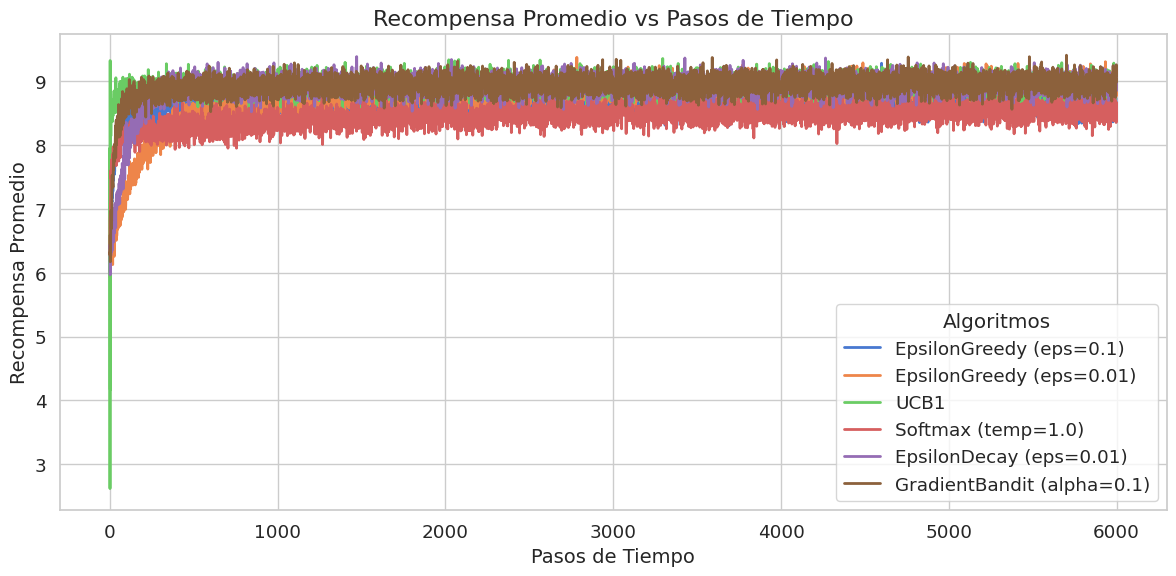

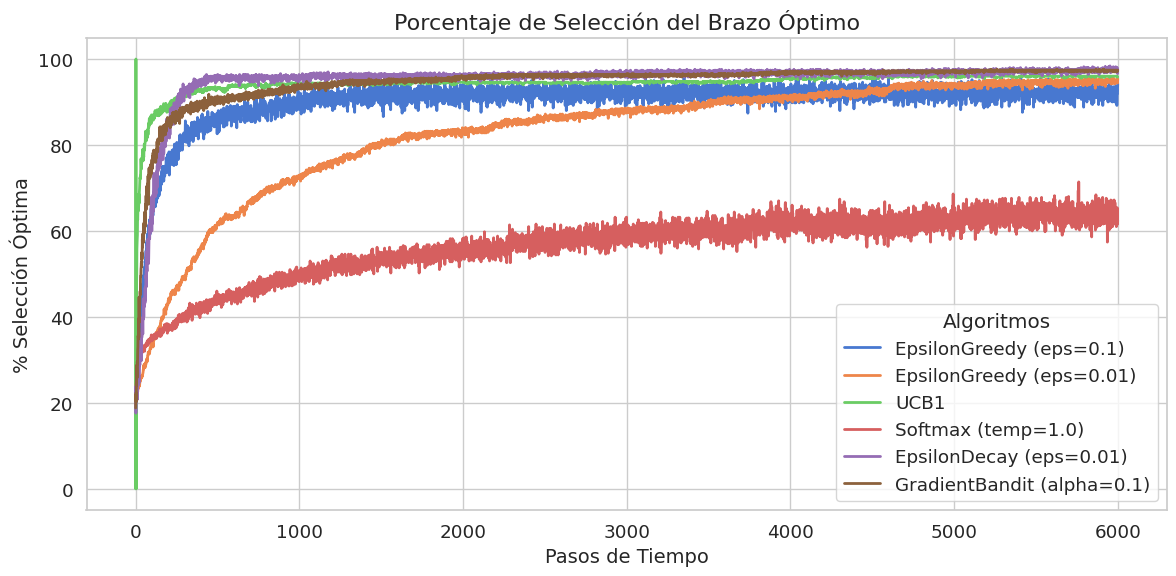

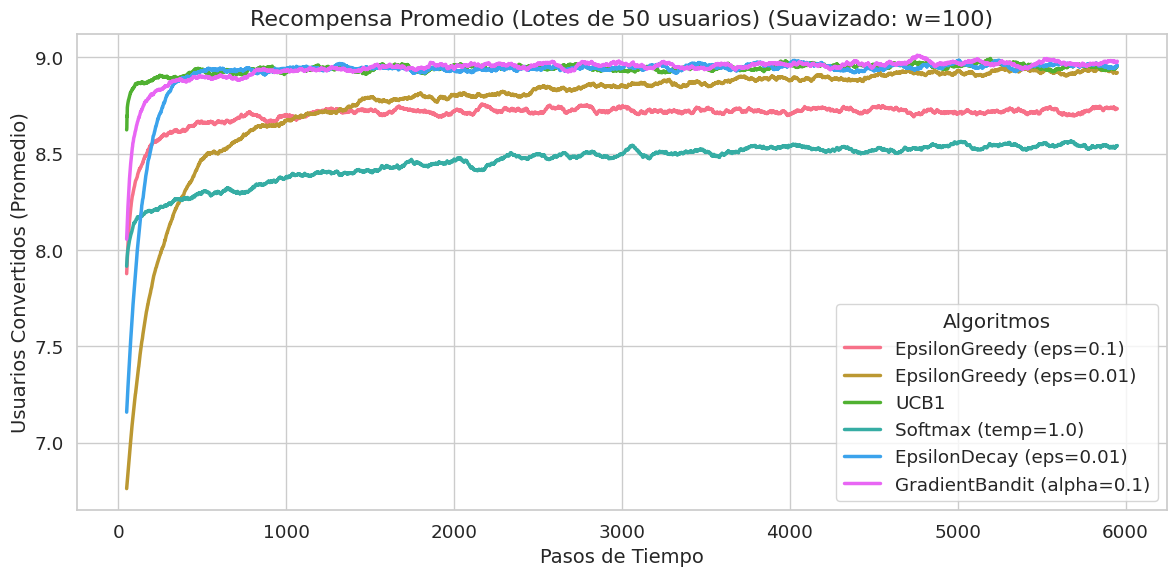

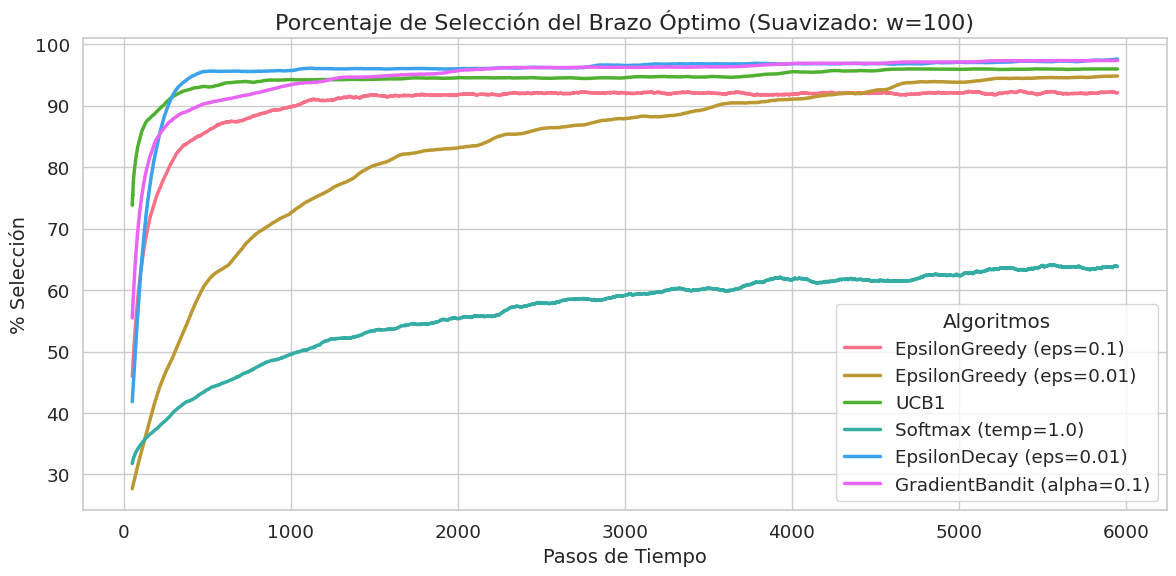

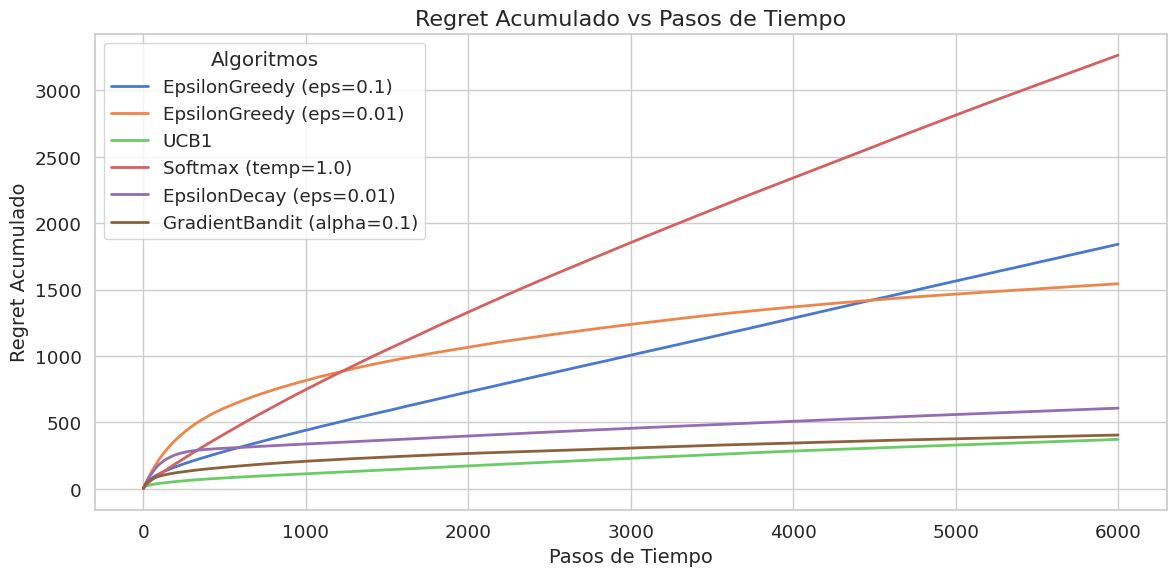

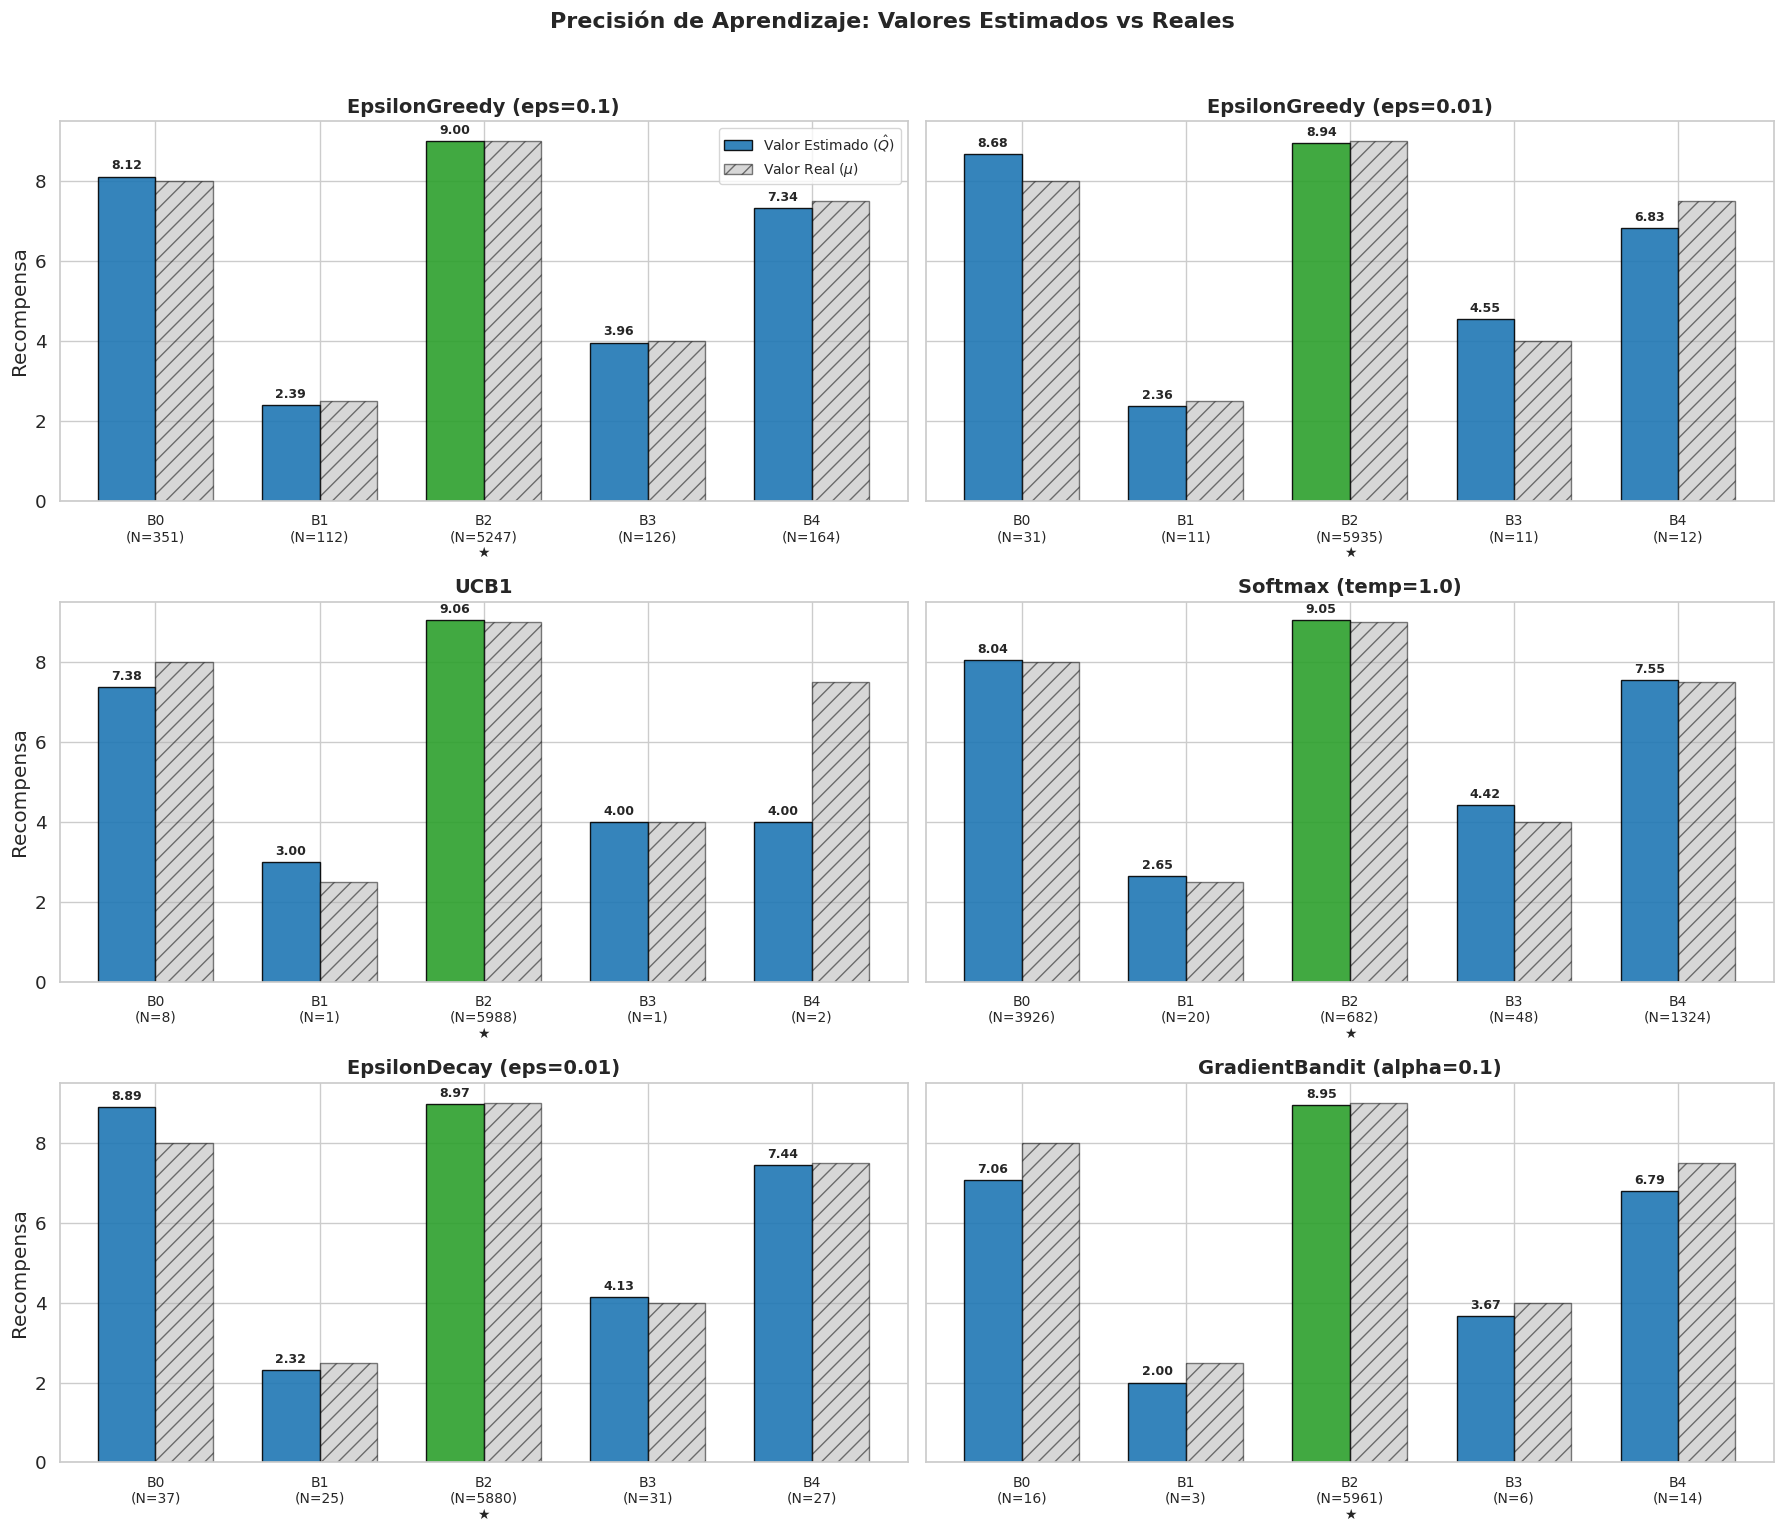

In [4]:
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics, plot_smoothed_curves

plot_average_rewards(N_STEPS, r_avg, algorithms_list)
plot_optimal_selections(N_STEPS, opt_avg, algorithms_list)
# 1. Gráfica de Recompensa Promedio (Suavizada)
# El valor óptimo es 9.0 (50 usuarios * 0.18)
plot_smoothed_curves(
    steps=N_STEPS, 
    data=r_avg, 
    algorithms=algorithms_list, 
    title=f"Recompensa Promedio (Lotes de {BATCH_SIZE} usuarios)", 
    ylabel="Usuarios Convertidos (Promedio)", 
    window_size=100,
)

# 2. Selección Óptima
plot_smoothed_curves(
    steps=N_STEPS, 
    data=opt_avg * 100, 
    algorithms=algorithms_list, 
    title="Porcentaje de Selección del Brazo Óptimo", 
    ylabel="% Selección", 
    window_size=100,
)

# 3. Regret Acumulado
plot_regret(N_STEPS, reg_avg, algorithms_list)

# 4. Estadísticas Finales
plot_arm_statistics(q_vals, counts, algorithms_list, optimal_arm_index=np.argmax(BANDIT_PROBS), true_means=[p * 50 for p in BANDIT_PROBS])

## 2. Análisis de Resultados: Distribución Binomial

En este escenario de **App de Delivery**, hemos introducido una complejidad adicional: la escala de la recompensa ($0$ a $50$) y su varianza asociada.

### A. Adaptación de los Algoritmos (Escala)
Un hallazgo clave es la sensibilidad de **Softmax** a la escala de la recompensa.
- En el experimento de Bernoulli (recompensa 0 o 1), una temperatura $\tau=0.1$ funcionaba bien.
- Aquí, con recompensas promedio de ~9, usar $\tau=0.1$ causaría que $e^{9/0.1} = e^{90}$ sea un número inmensamente grande, eliminando casi toda exploración (el algoritmo se comportaría como *Greedy* puro).
- Ajustando la temperatura a $\tau=1.0$ (o superior), Softmax recupera su capacidad de explorar, aunque sigue siendo difícil de calibrar comparado con UCB1.

### B. Robustez ante el Ruido (Varianza)
La **Distribución Binomial** introduce más ruido que la Bernoulli. Un brazo sub-óptimo como el A ($p=0.16$, esperado 8) puede generar frecuentemente recompensas de 10 o 11, engañando al algoritmo para que crea que es mejor que el óptimo C ($p=0.18$, esperado 9).
- **UCB1** maneja esto aumentando el término de incertidumbre, "desconfiando" de las medias hasta tener suficientes muestras. Vemos que su curva de aprendizaje es más lenta al principio comparada con Bernoulli, pero converge sólidamente.
- **Epsilon-Greedy** sufre más oscilaciones debido a este ruido, ya que su exploración es ciega y no basada en la varianza observada.

### C. Conclusión para Negocio
Para una startup de Delivery que realiza tests A/B continuos en lotes:
1.  **UCB1** es la opción más segura. Garantiza encontrar la mejor promoción sin necesidad de que un *Data Scientist* esté ajustando manualmente parámetros como $\epsilon$ o Temperatura cada vez que cambia el tamaño del lote ($n$).
2.  Si se requiere maximizar el beneficio a muy corto plazo (pocos días de campaña), **Epsilon-Decay** agresivo puede ser superior, explotando rápidamente la promoción que parece ganadora en los primeros lotes.